In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install netCDF4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.3 MB/s eta 0:00:00


In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'check6' in f.lower() or 'predictions' in f.lower():
            print(os.path.join(root, f))

/kaggle/input/datasets/divyanshyecho/check-6-all-predictions/check6_predictions.npy


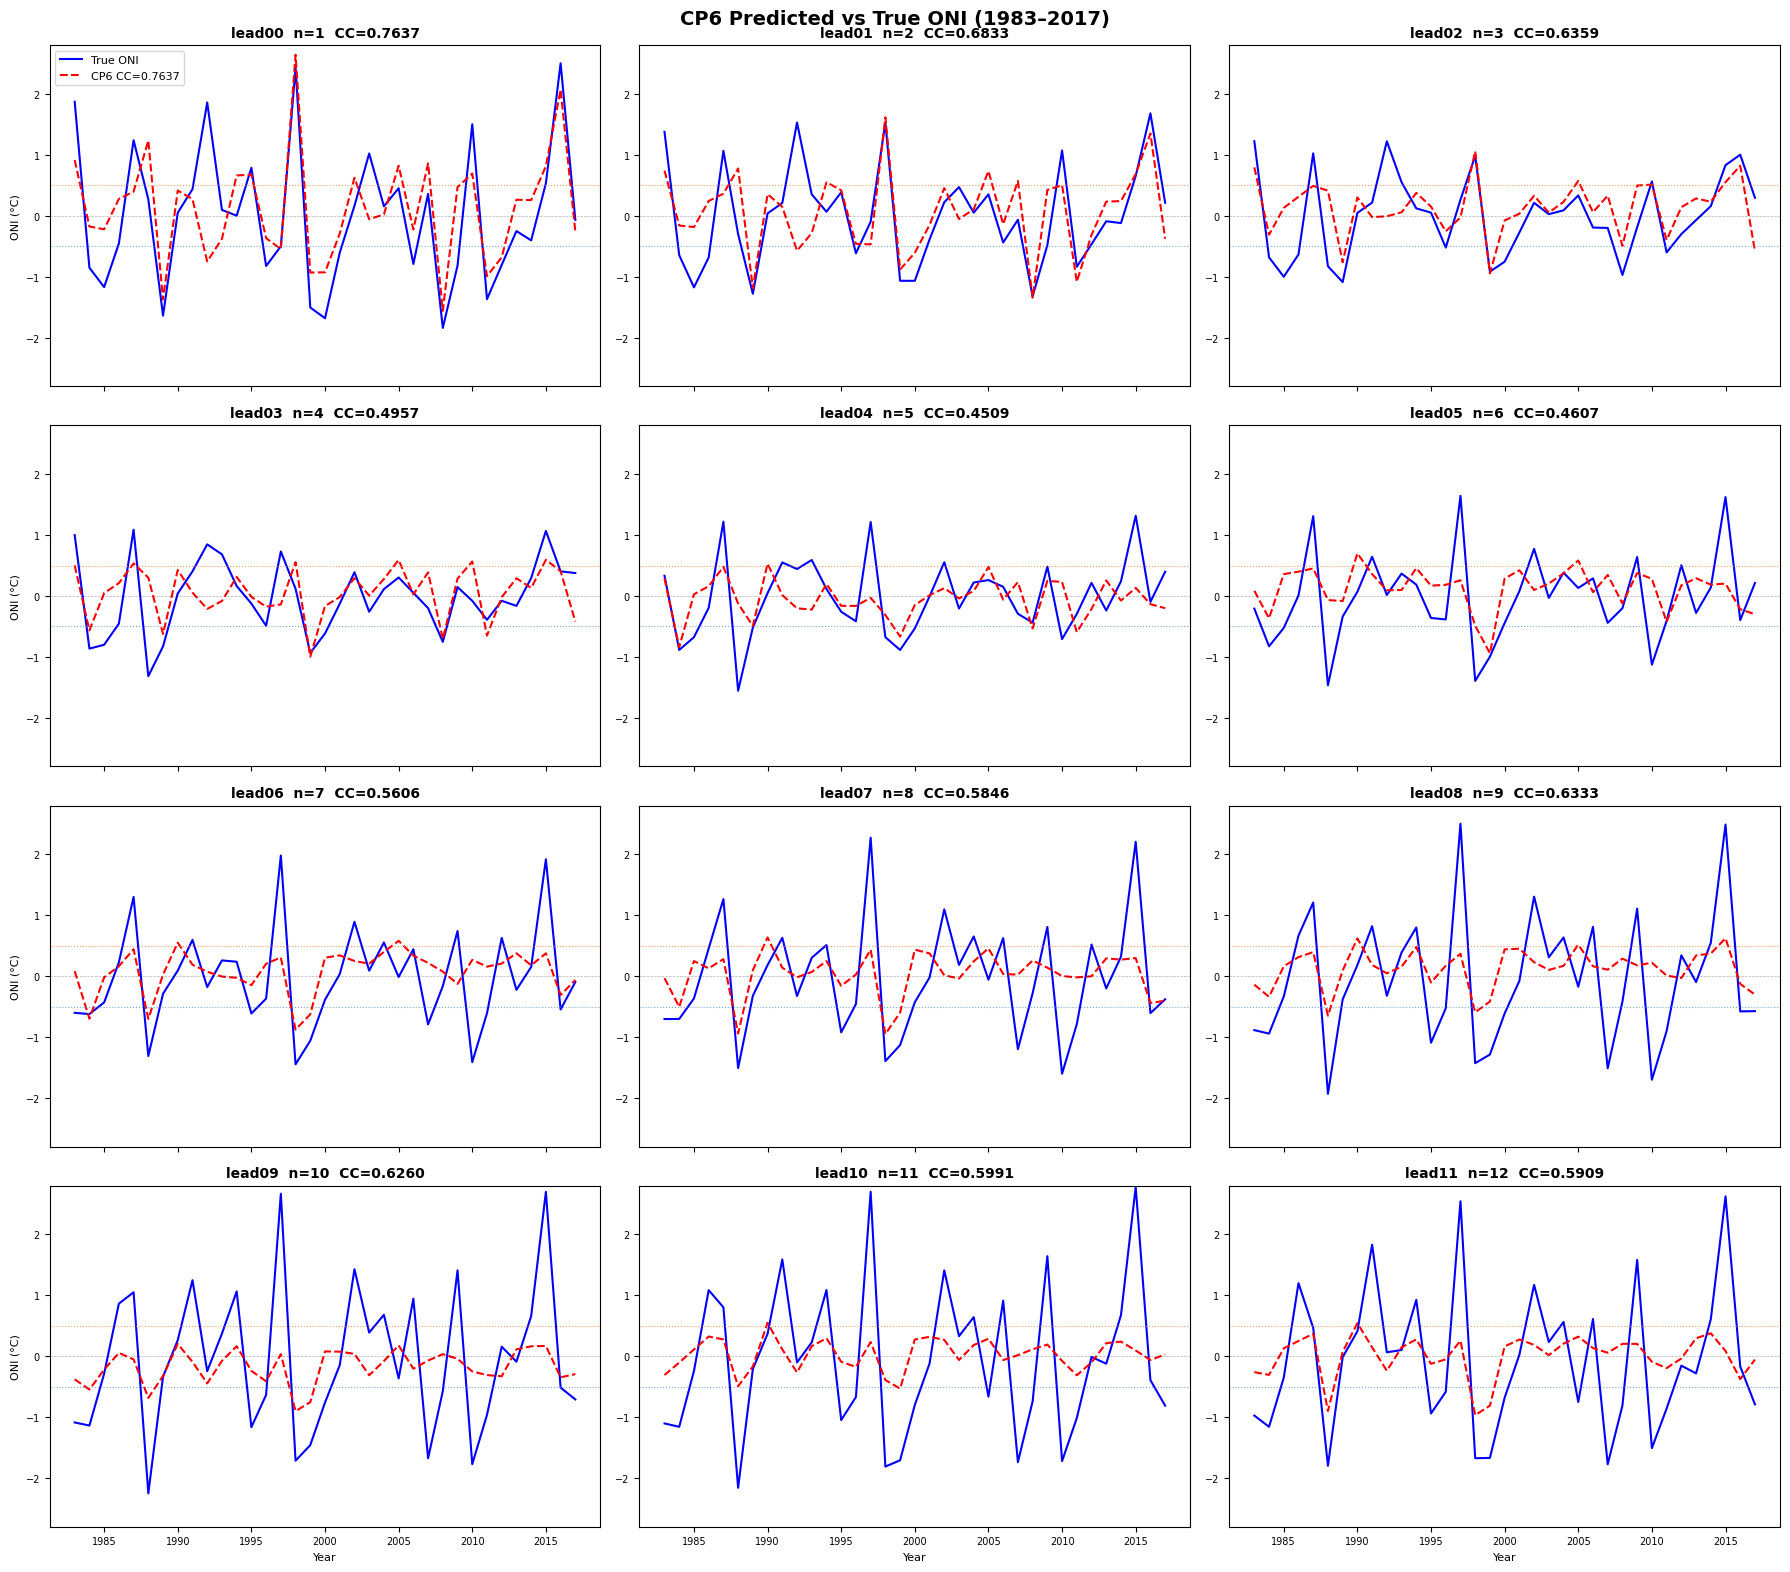

In [4]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Paths
BASE     = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset'
CP6_FILE = '/kaggle/input/datasets/divyanshyecho/check-6-all-predictions/check6_predictions.npy'
# Load CP6
cp6 = np.load(CP6_FILE, allow_pickle=True).item()

# Load true labels
def get_true(lead):
    f = f'{BASE}/GODAS.label.12mn_2mv.1982_2017.nc' if lead == 0 else f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'
    ds = nc.Dataset(f)
    pr = np.array(ds.variables['pr'][:]).astype('float32')
    ds.close()
    return pr[1:, lead, 0, 0]

YEARS = list(range(1983, 2018))

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True)
axes = axes.flatten()

for lead in range(12):
    ax  = axes[lead]
    key = f'lead{lead:02d}'
    Y   = get_true(lead)
    P   = cp6[key]
    cc  = pearsonr(P, Y)[0]

    ax.plot(YEARS, Y, 'b-',  lw=1.5, label='True ONI')
    ax.plot(YEARS, P, 'r--', lw=1.5, label=f'CP6 CC={cc:.4f}')
    ax.axhline( 0.5, color='#E87722',   lw=0.8, ls=':', alpha=0.7)
    ax.axhline(-0.5, color='steelblue', lw=0.8, ls=':', alpha=0.7)
    ax.axhline(0,    color='k',         lw=0.5, ls='--', alpha=0.3)
    ax.set_title(f'lead{lead:02d}  n={lead+1}  CC={cc:.4f}', fontsize=10, fontweight='bold')
    ax.set_ylim(-2.8, 2.8)
    ax.tick_params(labelsize=7)
    if lead >= 9: ax.set_xlabel('Year', fontsize=8)
    if lead % 3 == 0: ax.set_ylabel('ONI (°C)', fontsize=8)

axes[0].legend(fontsize=8)
fig.suptitle('CP6 Predicted vs True ONI (1983–2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cp6_vs_true_oni.png', dpi=150)
plt.show()

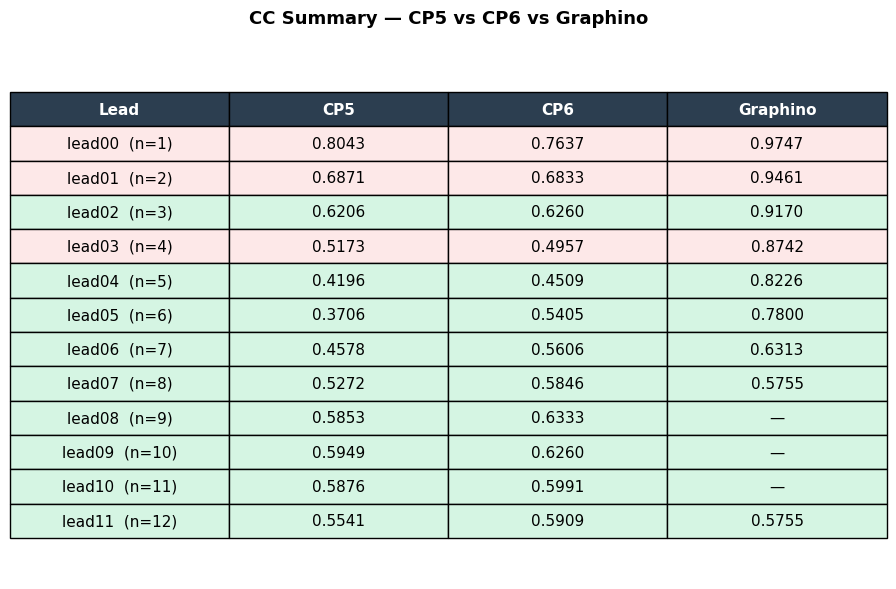

In [8]:
import matplotlib.pyplot as plt

cp5      = {0:0.8043, 1:0.6871, 2:0.6206, 3:0.5173, 4:0.4196, 5:0.3706, 6:0.4578, 7:0.5272, 8:0.5853, 9:0.5949, 10:0.5876, 11:0.5541}
cp6      = {0:0.7637, 1:0.6833, 2:0.6260, 3:0.4957, 4:0.4509, 5:0.5405, 6:0.5606, 7:0.5846, 8:0.6333, 9:0.6260, 10:0.5991, 11:0.5909}
graphino = {0:0.9747, 1:0.9461, 2:0.9170, 3:0.8742, 4:0.8226, 5:0.7800, 6:0.6313, 7:0.5755, 8:None, 9:None, 10:None, 11:0.5755}

rows = []
for lead in range(12):
    rows.append([
        f'lead{lead:02d}  (n={lead+1})',
        f'{cp5[lead]:.4f}',
        f'{cp6[lead]:.4f}',
        f'{graphino[lead]:.4f}' if graphino[lead] else '—'
    ])

fig, ax = plt.subplots(figsize=(9, 6))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=['Lead', 'CP5', 'CP6', 'Graphino'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for j in range(4):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, 13):
    lead = i - 1
    c5 = cp5[lead]
    c6 = cp6[lead]
    for j in range(4):
        if c6 > c5:
            table[i, j].set_facecolor('#d5f5e3')
        else:
            table[i, j].set_facecolor('#fde8e8')

plt.title('CC Summary — CP5 vs CP6 vs Graphino', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('cc_table.png', dpi=150, bbox_inches='tight')
plt.show()

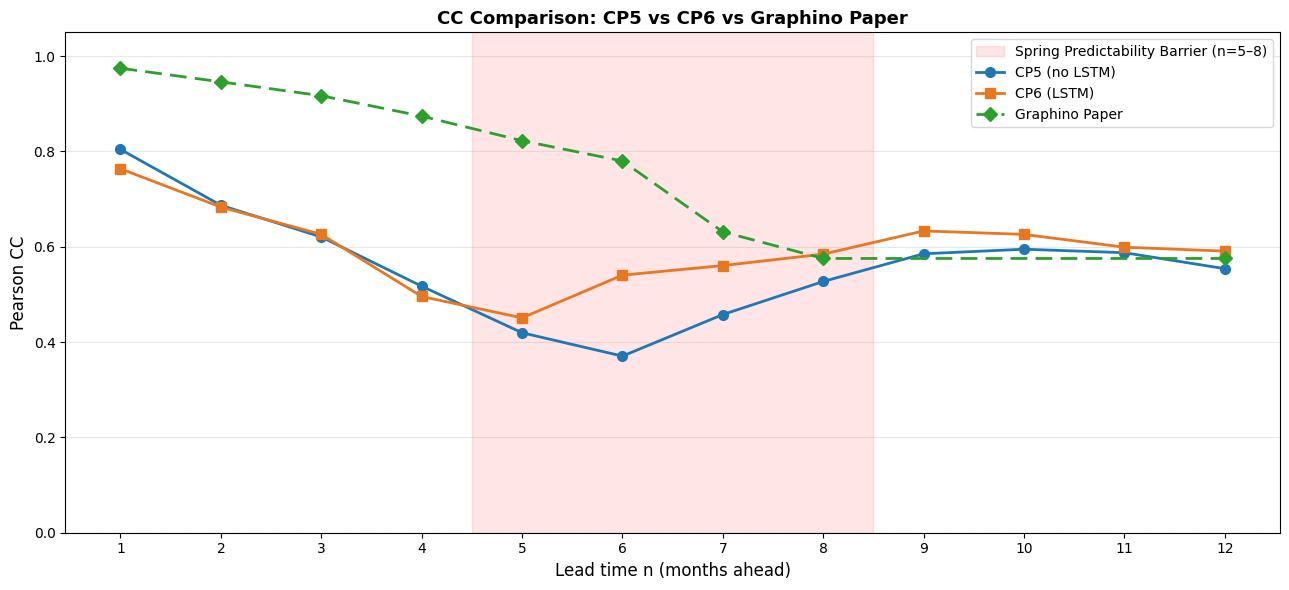

In [10]:
import matplotlib.pyplot as plt

cp5      = {1:0.8043, 2:0.6871, 3:0.6206, 4:0.5173, 5:0.4196, 6:0.3706, 7:0.4578, 8:0.5272, 9:0.5853, 10:0.5949, 11:0.5876, 12:0.5541}
cp6      = {1:0.7637, 2:0.6833, 3:0.6260, 4:0.4957, 5:0.4509, 6:0.5405, 7:0.5606, 8:0.5846, 9:0.6333, 10:0.6260, 11:0.5991, 12:0.5909}
graphino = {1:0.9747, 2:0.9461, 3:0.9170, 4:0.8742, 5:0.8226, 6:0.7800, 7:0.6313, 8:0.5755, 12:0.5755}

n_all = list(range(1, 13))
cp5_v = [cp5[n] for n in n_all]
cp6_v = [cp6[n] for n in n_all]
g_n   = sorted(graphino.keys())
g_v   = [graphino[n] for n in g_n]

fig, ax = plt.subplots(figsize=(13, 6))

ax.axvspan(4.5, 8.5, alpha=0.10, color='red', label='Spring Predictability Barrier (n=5–8)')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.3)

ax.plot(n_all, cp5_v, 'o-',  color='#1F77B4', lw=2, ms=7, label='CP5 (no LSTM)')
ax.plot(n_all, cp6_v, 's-',  color='#E87722', lw=2, ms=7, label='CP6 (LSTM)')
ax.plot(g_n,   g_v,   'D--', color='#2CA02C', lw=2, ms=7, label='Graphino Paper', dashes=(6,3))

ax.set_xlabel('Lead time n (months ahead)', fontsize=12)
ax.set_ylabel('Pearson CC', fontsize=12)
ax.set_title('CC Comparison: CP5 vs CP6 vs Graphino Paper', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cc_comparison.png', dpi=150)
plt.show()